# **Шаг 0: Import and Reading Data**

In [ ]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/jorisvandenbossche/pandas-tutorial/master/data/titanic.csv')

# **Шаг 1: Data Understanding**


*   Dataframe shape
*   head and tail
*   dtypes
*   columns
*   describe








In [ ]:
df.shape

# Теперь мы точно знаем размер нашего датасета

(891, 12)

In [ ]:
# Первые пять строк нашего датасета

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Последние пять строк нашего датасета

df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **Шаг 2: Data Preparation**


*   Dropping irrelevant columns and rows
*   Identifying duplicated columns
*   Renaming Columns
*   Feature Creation




In [ ]:
# ищем дубликаты в датасете

df.duplicated().sum()

np.int64(0)

In [ ]:
# ищем пропущенные значения в датасете

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# заменяем пропущенные значения в колонке Age, на медиану по возрасту

df['Age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Замена пропущенных значений порта посадки на моду

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
df['Embarked'].isnull().sum()

np.int64(0)

In [ ]:
# Просто пример того как бы мы могли поменять имя колонки

df = df.rename(columns = {'SibSp':'Siblings'})

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Siblings,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df = df.rename(columns = {'Siblings':'SibSp'})

# **Шаг 3: Feature Understanding**

(Univariate analysis)
*   Plotting Feature Distributions
*   Histogram
*   KDE
*   Boxplot




In [ ]:
df['Age'].between(0, 18).sum()

np.int64(139)

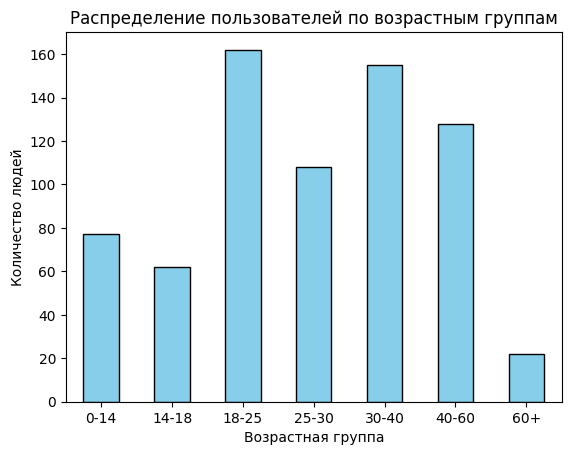

In [ ]:
# Задаем границы интервалов и их названия
bins = [0, 14, 18, 25, 30, 40, 60, float('inf')]
labels = ['0-14', '14-18', '18-25', '25-30', '30-40','40-60', '60+']

# Делим возраст на группы и считаем количество в каждой
age_groups = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
group_counts = age_groups.value_counts().sort_index()

# Строим красивую диаграмму
group_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Добавляем оформление
plt.title('Распределение пользователей по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Количество людей')
plt.xticks(rotation=0)  # Чтобы подписи на оси X были горизонтальными
plt.show()

Количество людей по полу:
Sex
male      577
female    314
Name: count, dtype: int64


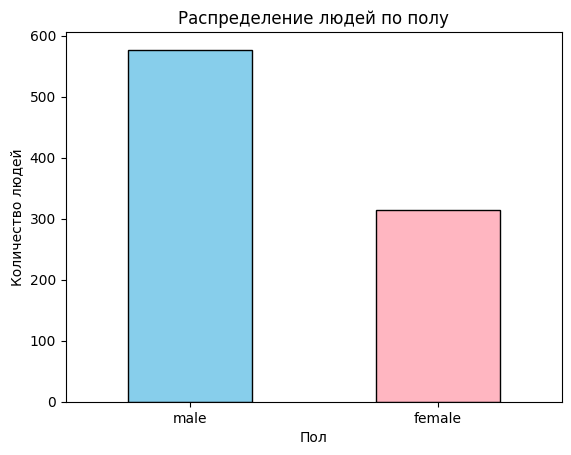

In [ ]:
group_counts = df['Sex'].value_counts()

# Выводим точное количество в консоль
print("Количество людей по полу:")
print(group_counts)

# Строим диаграмму
group_counts.plot(kind='bar', color=['skyblue', 'lightpink'], edgecolor='black')


# Добавляем оформление
plt.title('Распределение людей по полу')
plt.xlabel('Пол')
plt.ylabel('Количество людей')
plt.xticks(rotation=0)  # Чтобы подписи на оси X были горизонтальными
plt.show()

# Задания по датасету 'Титаника'



---


## 1. Data Selection

1. Select only the columns Name, Sex, and Age and display the first 5
rows.








In [ ]:
df[['Name', 'Sex', 'Age']].head(5)

,Name,Sex,Age
0,"Braund, Mr. Owen Harris",male,22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0
2,"Heikkinen, Miss. Laina",female,26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0
4,"Allen, Mr. William Henry",male,35.0


2. Display rows where Fare is greater than 50.

In [ ]:
df[df['Fare'] > 50]

,PassengerId,Survived,Pclass,Name,Sex,Age,Siblings,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
...,...,...,...,...,...,...,...,...,...,...,...,...
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S


# 2. DataFiltering:

1. Filter and display the rows where Survived is 1 and Pclass is 3.


In [ ]:
df[(df['Survived'] == 1) & (df['Pclass'] == 3)]

,PassengerId,Survived,Pclass,Name,Sex,Age,Siblings,Parch,Ticket,Fare,Cabin,Embarked
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
838,839,1,3,"Chip, Mr. Chang",male,32.0,0,0,1601,56.4958,NaN,S
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
858,859,1,3,"Baclini, Mrs. Solomon (Latifa Qurban)",female,24.0,0,3,2666,19.2583,NaN,C
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S


2. Find all passengers who embarked from 'C' and paid more than 50 for
their ticket.


In [ ]:
df[(df['Embarked'] == 'C') & (df['Fare'] > 50)]

,PassengerId,Survived,Pclass,Name,Sex,Age,Siblings,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
...,...,...,...,...,...,...,...,...,...,...,...,...
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
789,790,0,1,"Guggenheim, Mr. Benjamin",male,46.0,0,0,PC 17593,79.2000,B82 B84,C
835,836,1,1,"Compton, Miss. Sara Rebecca",female,39.0,1,1,PC 17756,83.1583,E49,C
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C


# 3. Aggregation and Grouping:

1. Calculate the average age of passengers for each Pclass.



In [ ]:
df.groupby('Pclass')['Age'].mean()

,Age
Pclass,
1,38.233441
2,29.877630
3,25.140620


2. Find the total number of survivors grouped by Pclass.


In [ ]:
df.groupby('Pclass')['Survived'].sum()

,Survived
Pclass,
1,136
2,87
3,119


3. Find the maximum Fare paid for each class (Pclass).

In [ ]:
df.groupby('Pclass')['Fare'].max()

,Fare
Pclass,
1,512.3292
2,73.5000
3,69.5500


# 5. Handling Missing Values:



1. Fill missing values in the Age column with the median age.





In [ ]:
df['Age'].isnull().sum()

np.int64(177)

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'].isnull().sum()

np.int64(0)

2. Drop rows where the Cabin column has missing values.

In [ ]:
df['Cabin'].isnull().sum()

np.int64(687)

In [ ]:
df.dropna(subset = ['Cabin'], inplace = True)
df['Cabin'].isnull().sum()

np.int64(0)

# 5. Creating New Columns:

1. Create a new column called FamilySize which is the sum of SibSp and Parch.


In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch']
df['FamilySize'].head()

,FamilySize
0,1
1,1
2,0
3,1
4,0


2.  Create a new column Fare_per_person which is the Fare divided by FamilySize + 1.


In [ ]:
df['Fare_per_person'] = df['Fare'] / (df['FamilySize'] + 1)
df['Fare_per_person'].head()

,Fare_per_person
0,3.62500
1,35.64165
2,7.92500
3,26.55000
4,8.05000


# 6. Sorting Data:

1. Sort the dataset by Fare in descending order.


In [ ]:
df.sort_values(by = 'Fare', ascending = False).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Fare_per_person
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,True,C,1,256.164600
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,True,C,0,512.329200
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,True,C,0,512.329200
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,True,S,5,43.833333
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,True,S,5,43.833333


2. Sort the dataset by Age and Fare in ascending order.

In [ ]:
df.sort_values(by = ['Age', 'Fare'], ascending = True).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Fare_per_person
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,True,C,1,4.258350
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,True,S,2,4.833333
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,True,C,3,4.814575
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,True,C,3,4.814575
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,True,S,2,6.250000


# 6. String Operations:

1. Extract the last name of each passenger into a new column called
LastName.


In [ ]:
df['LastName'] = df['Name'].str.split(',').str[0].str.strip()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Fare_per_person,LastName,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,True,S,1,3.62500,Braund,Mr. Owen Harris
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,True,C,1,35.64165,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,True,S,0,7.92500,Heikkinen,Miss. Laina
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,True,S,1,26.55000,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,True,S,0,8.05000,Allen,Mr. William Henry


2. Create a new column Title by extracting titles (like Mr, Mrs, Miss)
from the Name column.


In [ ]:
df['Title'] = df['Name'].str.split().str[1]
df['Title'].head()

,Title
0,Mr.
1,Mrs.
2,Miss.
3,Mrs.
4,Mr.


# 7. Conditional Columns:
1. Create a new column AgeGroup that categorizes passengers as 'Child', 'Adult', or 'Senior' based on their age.


In [ ]:
bins = [0, 17, 63, 120]
labels = ['Child', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
df[['Age', 'AgeGroup']].head(10)

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult
5,28.0,Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Adult
9,14.0,Child


# **Conlcusion:**

### В ходе анализа датасета Titanic мы прошли основные этапы работы с данными в Pandas: загрузили данные, изучили их структуру, провели базовую очистку и выполнили первичный анализ.

## Изначально датасет содержал **891 строку и 12 столбцов**. С помощью `shape`, `head()`, `tail()`, `dtypes`, `columns` и `describe()` мы изучили структуру данных, типы признаков и основные статистические характеристики. Средний возраст пассажиров составлял около **29,7 лет**, а средняя стоимость билета — около **32,2**.

### На этапе подготовки данных мы проверили наличие дубликатов и пропущенных значений. Полных дубликатов обнаружено не было. При этом пропуски присутствовали в столбцах `Age`, `Cabin` и `Embarked`: **177**, **687** и **2** пропуска соответственно. Пропущенные значения `Age` были заменены медианным возрастом, а пропуски `Embarked` — наиболее часто встречающимся значением. Для `Cabin` мы удалили строки с отсутствующими значениями.

### Также мы научились фильтровать данные по нескольким условиям. Например, находили пассажиров третьего класса, которые выжили, а также пассажиров, отправившихся из `C` и заплативших более 50 за билет. Это позволило попрактиковаться в работе с логическими условиями `&`, `|`, а также в использовании `query()`.

### С помощью `groupby()` мы провели базовую агрегацию данных. Средний возраст пассажиров первого класса составил примерно **38,2 года**, второго — **29,9**, третьего — **25,1**. Количество выживших по классам составило **136 пассажиров первого класса, 87 второго и 119 третьего**. Максимальная стоимость билета также значительно отличалась между классами: в первом классе она достигала **512,33**, тогда как во втором и третьем — **73,50** и **69,55** соответственно.

### Кроме того, мы создали новые признаки. `FamilySize` показывает размер семьи на основе `SibSp` и `Parch`, а `Fare_per_person` позволяет оценить стоимость билета в расчёте на одного человека с учётом размера семьи. Мы также использовали строковые операции для извлечения фамилии (`LastName`) и обращения пассажира (`Title`) из имени.
###Для дальнейшего анализа возраст пассажиров был разделён на категории `Child`, `Adult` и `Senior`. Таким образом, мы научились преобразовывать непрерывный числовой признак в более удобные для анализа категории с помощью `pd.cut()`.

###В результате этого проекта мы закрепили основные навыки работы с Pandas: **изучение DataFrame, выбор данных, фильтрацию, обработку пропусков, группировку и агрегацию, сортировку, создание новых столбцов, работу со строками и категоризацию данных**.

###Следующим логичным этапом будет расширить анализ с помощью визуализации и более глубокого исследования взаимосвязи между полом, возрастом, классом, стоимостью билета и выживаемостью.
